# 🎮💹 NOTEBOOK DE VELJKO L'ANALYSTE (et pro gamer)	🎮💹

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)
**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le 

## === Pour importer les fonctions du fichier "outils_eda", si vous en avez besoin lors de votre analyse ===

import sys
import os

sys.path.append("../dorian_code") -> permet à Python d'aller lire les fichiers présent dans le dossier "dorian_code"

from outils_eda import * -> importe le fichier "outils_eda" dont ces fonctions que vous pouvez utiliser lors de l'analyse !

Important des différents package

In [42]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [43]:
path_parquet_file = r"C:\Users\veljk\economic_research\DATALAKE\PARQUET_FOLDER\main_detrended.parquet"

df = pd.read_parquet(path_parquet_file)


df_detrended = df[[
    'year',                  # Variable temporelle pour le contrôle des chocs de période
    'gdp_nominal_stat',      # Variable dépendante (Y) : Croissance du PIB nominal
    'expected_inflation',    # Contrôle : Anticipations des agents (clé pour la courbe de Phillips)
    'taux_changes_stat',     # Contrôle : Canal de transmission externe (Compétitivité-prix)
    'cpi_stat',              # Variable dépendante alternative : Stabilité des prix
    'taux_directeur',        # Variable d'intérêt (X) : Instrument de politique monétaire
    'export_stat',           # Contrôle : Demande extérieure nette
    'import_stat_stat',      # Contrôle : Absorption de la demande domestique
    'yield_perpetual_stat',  # Contrôle : Taux longs (Anticipations de marché et coût du capital)
    'oil_price_stat',        # Contrôle : Chocs d'offre exogènes (Poussée inflationniste)
    'gdp_cycle',             # Indicateur conjoncturel (Écarts à court terme)
    'gdp_trend_stat_stat',   # Contrôle de la croissance potentielle de long terme
    'output_gap'             # Mesure de la pression sur les capacités de production
]].copy()

In [44]:
# 1. Régime "Gold Standard" : on marque d'un '1' toutes les années jusqu'à 1932 inclus
df_detrended['d_gold'] = np.where(df_detrended['year'] <= 1932, 1, 0)

# 2. Régime "Bretton Woods" : on marque d'un '1' l'intervalle 1944-1971
df_detrended['d_woods'] = np.where((df_detrended['year'] >= 1944) & (df_detrended['year'] <= 1971), 1, 0)

# 3. Régime "Floating" (Changes flottants) : on marque d'un '1' tout ce qui suit 1971
df_detrended['d_floating'] = np.where(df_detrended['year'] >= 1972, 1, 0)

In [45]:
# --- CRÉATION DES VARIABLES D'INTERACTION (EFFICACITÉ PAR RÉGIME) ---

# On multiplie le taux directeur par la dummy 'Bretton Woods'
# Résultat : la valeur du taux uniquement entre 1944 et 1971, sinon 0.
df_detrended['woods_int'] = df_detrended['taux_directeur'] * df_detrended['d_woods']

# On multiplie le taux directeur par la dummy 'Floating'
# Résultat : la valeur du taux uniquement pour la période après 1971, sinon 0.
df_detrended['floating_int'] = df_detrended['taux_directeur'] * df_detrended['d_floating']

In [46]:
# --- PRÉPARATION DES VARIABLES DÉPENDANTES (STATIONNARISÉES) ---
Y_gdp = df_detrended['gdp_nominal_stat']       
Y_inflation = df_detrended['cpi_stat']         
Y_change = df_detrended['taux_changes_stat']   

# --- CONSTRUCTION DE LA MATRICE DES RÉGRESSEURS (X) ---
# Choix méthodologique : Le 'Gold Standard' est défini comme la période de référence.
# d_woods & d_floating : Captent l'écart de niveau structurel (intercept) par rapport au Gold Standard.
# gold_int, woods_int, floating_int : Mesurent l'efficacité marginale du taux directeur propre à chaque régime.
X = df_detrended[['taux_directeur','d_woods', 'd_floating','woods_int', 'floating_int']]

# Ajout de la constante : Dans cette configuration, 'const' représente l'intercept du Gold Standard.
X = sm.add_constant(X)

# --- ESTIMATION DES MODÈLES OLS ---
model_gdp_1  = sm.OLS(Y_gdp, X, missing='drop').fit()
model_inf_1  = sm.OLS(Y_inflation, X, missing='drop').fit()
model_exch_1 = sm.OLS(Y_change, X, missing='drop').fit()

# --- AFFICHAGE ET DIAGNOSTIC ---

print("=== MODÈLE 1 : IMPACT SUR LE PIB NOMINAL ===")
print(model_gdp_1.summary())

print("\n=== MODÈLE 2 : IMPACT SUR L'INFLATION (CPI) ===")
print(model_inf_1.summary())

print("\n=== MODÈLE 3 : IMPACT SUR LE TAUX DE CHANGE ===")
print(model_exch_1.summary())

=== MODÈLE 1 : IMPACT SUR LE PIB NOMINAL ===
                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.420
Method:                 Least Squares   F-statistic:                     16.09
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.38e-11
Time:                        11:39:14   Log-Likelihood:                 218.37
No. Observations:                 105   AIC:                            -424.7
Df Residuals:                      99   BIC:                            -408.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [47]:
# --- CONSTRUCTION DE LA MATRICE DE RÉGRESSION COMPLÈTE (C) ---
C = df_detrended[[
    # Dummies de Niveau (Intercepts relatifs) : 
    # Le 'Gold Standard' est la référence omise. Ces deux variables captent l'écart structurel.
    'd_woods', 'd_floating',

    # La variable d'intérêt :
    'taux_directeur',
    # Interactions: 
    'woods_int', 'floating_int', 
    
    # Contrôles :
    'export_stat', 'import_stat_stat','output_gap','gdp_cycle', 'yield_perpetual_stat','oil_price_stat','gdp_trend_stat_stat','expected_inflation'                     
]]

# Ajout de la constante : Dans cette spécification, la constante est l'intercept du 'Gold Standard'.
C = sm.add_constant(C)

# --- ESTIMATION DES MODÈLES OLS AVEC VARIABLES DE CONTRÔLE ---
# Note : L'ajout de contrôles réduit normalement la variance de l'erreur et affine les coefficients '_int'.
model_gdp_2   = sm.OLS(Y_gdp, C, missing='drop').fit()
model_inf_2   = sm.OLS(Y_inflation, C, missing='drop').fit()
model_exch_2  = sm.OLS(Y_change, C, missing='drop').fit()

# --- AFFICHAGE DES RÉSULTATS DÉTAILLÉS ---

print("=== MODÈLE PIB (AVEC CONTRÔLES) ===")
# On observe ici si l'efficacité du taux survit à l'inclusion du cycle économique.
print(model_gdp_2.summary())

print("\n=== MODÈLE INFLATION (AVEC CONTRÔLES) ===")
# Crucial : L'impact du prix du pétrole et des anticipations sur la dynamique des prix.
print(model_inf_2.summary())

print("\n=== MODÈLE CHANGE (AVEC CONTRÔLES) ===")
# On vérifie si les variables commerciales (exports/imports) stabilisent les résidus du change.
print(model_exch_2.summary())

=== MODÈLE PIB (AVEC CONTRÔLES) ===
                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     19.79
Date:                Thu, 07 May 2026   Prob (F-statistic):           3.98e-21
Time:                        11:39:14   Log-Likelihood:                 257.60
No. Observations:                 105   AIC:                            -487.2
Df Residuals:                      91   BIC:                            -450.0
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

In [48]:
import sys

sys.path.append("../dorian_code")

cols_selection = ['year',
    'taux_directeur', 
    'taux_changes_stat', 
    'yield_perpetual_stat', 
    'cpi_stat', 
    'expected_inflation',
    'output_gap',
    'export_stat',
    'import_stat_stat', 
    'oil_price_stat',
    'gdp_cycle', 
    'gdp_nominal_stat', 
    'gdp_trend_stat_stat'
]

#corr_matrix(df_detrended[cols_selection])

In [49]:
C_gdp = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int',                                      
    'yield_perpetual_stat',                  
    'oil_price_stat',                     
    'gdp_trend_stat_stat',
    'expected_inflation'            
]]

#'export_stat', 'import_stat_stat', 
# 'output_gap','gdp_cycle' ---> Strong Multicolinéarité 

C_gdp = sm.add_constant(C_gdp)
model_gdp_3 = sm.OLS(Y_gdp, C_gdp, missing='drop').fit()
print(model_gdp_3.summary())

C_inf = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat'
]]

#'output_gap','gdp_cycle','expected_inflation'

C_inf = sm.add_constant(C_inf)
model_inf_3 = sm.OLS(Y_inflation, C_inf, missing='drop').fit()
print(model_inf_3.summary())

C_exch = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat',      
    'expected_inflation'                 
]]

#'output_gap', "gdp_cycle"

C_exch = sm.add_constant(C_exch)
model_exch_3 = sm.OLS(Y_change, C_exch, missing='drop').fit()
print(model_exch_3.summary())

#tex_table = model_robust2_exch.summary().as_latex()

#with open("Exch_gdp_cycle", "w") as f:
    #f.write(tex_table)


                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     27.68
Date:                Thu, 07 May 2026   Prob (F-statistic):           6.97e-23
Time:                        11:39:14   Log-Likelihood:                 254.71
No. Observations:                 105   AIC:                            -489.4
Df Residuals:                      95   BIC:                            -462.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0187 

In [50]:
model_robust_gdp = sm.OLS(Y_gdp, C_gdp, missing='drop').fit(cov_type='HC1')
model_robust_inf = sm.OLS(Y_inflation, C_inf, missing='drop').fit(cov_type='HC1')
model_robust_exch = sm.OLS(Y_change, C_exch, missing='drop').fit(cov_type='HC1')
#print(model_robust_gdp.summary())
#print(model_robust_inf.summary())
#print(model_robust_exch.summary())

In [51]:
model_robust2_gdp = sm.OLS(Y_gdp, C_gdp, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
model_robust2_inf = sm.OLS(Y_inflation, C_inf, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
model_robust2_exch = sm.OLS(Y_change, C_exch, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
#print(model_robust2_gdp.summary())
#print(model_robust2_inf.summary())
#print(model_robust2_exch.summary())

In [52]:
df_detrended['taux_directeur_sq'] = df_detrended['taux_directeur'] ** 2
df_detrended['woods_int_sq']    = df_detrended['woods_int'] ** 2
df_detrended['floating_int_sq'] = df_detrended['floating_int'] ** 2


C_gdp_sq = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'taux_directeur_sq','woods_int_sq','floating_int_sq',                          
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat',
    'expected_inflation'                                             
]]


C_gdp_sq = sm.add_constant(C_gdp_sq)
model_gdp_sq = sm.OLS(Y_gdp, C_gdp_sq, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model_gdp_sq.summary())

C_inf_sq = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'taux_directeur_sq','woods_int_sq','floating_int_sq',   
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat'     
]]

C_inf_sq = sm.add_constant(C_inf_sq)
model_inf_sq = sm.OLS(Y_inflation, C_inf_sq, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model_inf_sq.summary())

C_exch_sq = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'taux_directeur_sq','woods_int_sq','floating_int_sq',   
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat',      
    'expected_inflation'                     
]]

C_exch_sq = sm.add_constant(C_exch_sq)
model_exch_sq = sm.OLS(Y_change, C_exch_sq, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model_exch_sq.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     27.65
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.17e-25
Time:                        11:39:15   Log-Likelihood:                 256.25
No. Observations:                 105   AIC:                            -486.5
Df Residuals:                      92   BIC:                            -452.0
Df Model:                          12                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0550 

| | | |
|---|---|---|
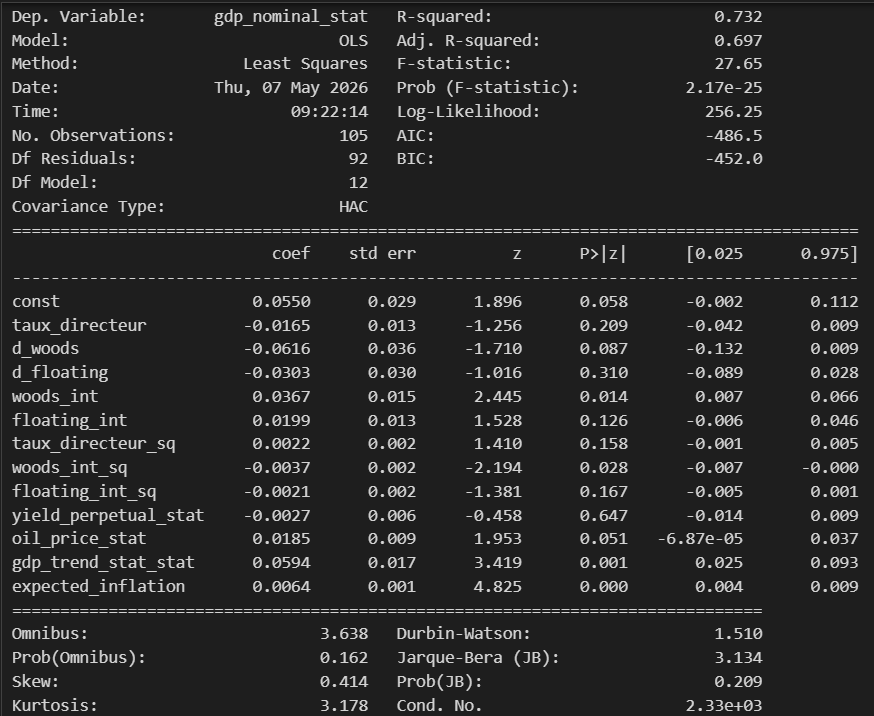 | 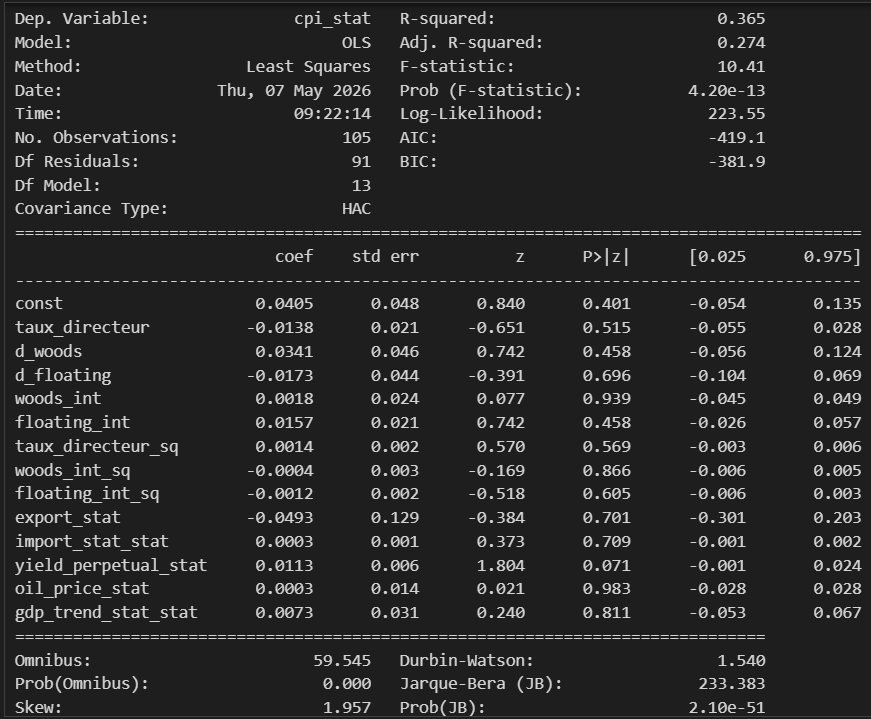 | 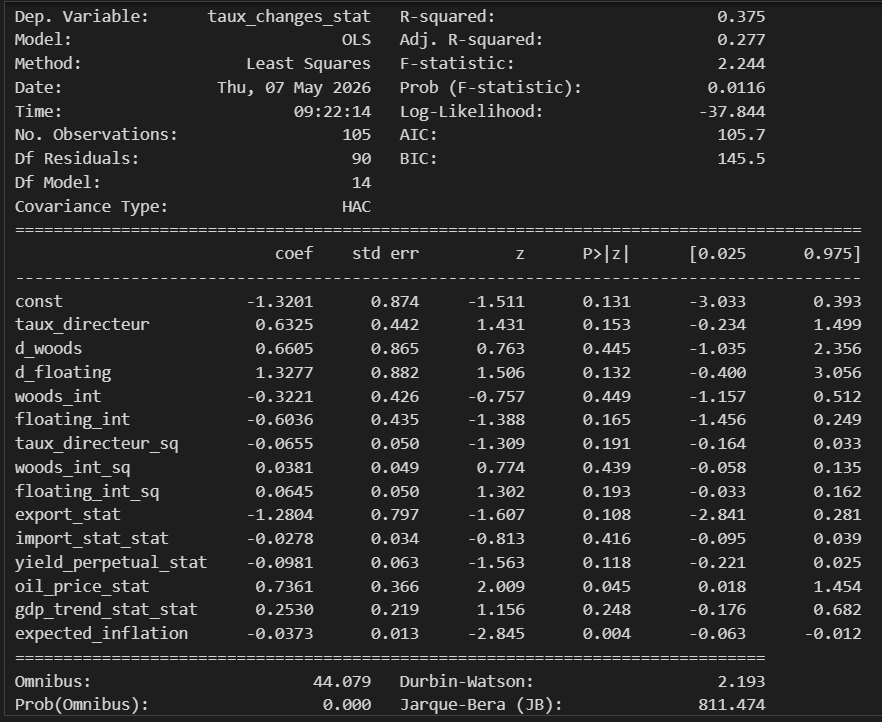


In [53]:
from statsmodels.stats.outliers_influence import reset_ramsey
test_reset = reset_ramsey(model_robust2_gdp, degree=3)
test_reset2 = reset_ramsey(model_robust2_inf, degree=3)
test_reset3 = reset_ramsey(model_robust2_exch, degree=3)
print("--- TEST DE RAMSEY (RESET) ---")
print(test_reset)
print(test_reset2)
print(test_reset3)

--- TEST DE RAMSEY (RESET) ---
<F test: F=3.375546057669198, p=0.03844022793416615, df_denom=93, df_num=2>
<F test: F=4.649516889329285, p=0.011923290421070019, df_denom=92, df_num=2>
<F test: F=20.562919292234596, p=4.279966988799242e-08, df_denom=91, df_num=2>


In [54]:
test_reset = reset_ramsey(model_gdp_sq, degree=3)
test_reset2 = reset_ramsey(model_inf_sq, degree=3)
test_reset3 = reset_ramsey(model_exch_sq, degree=3)
print("--- TEST DE RAMSEY (RESET) ---")
print(test_reset)
print(test_reset2)
print(test_reset3)

--- TEST DE RAMSEY (RESET) ---
<F test: F=3.0041430587592894, p=0.05457838241146342, df_denom=90, df_num=2>
<F test: F=7.922500152463693, p=0.0006815245741494054, df_denom=89, df_num=2>
<F test: F=37.97711301040168, p=1.2865968948770976e-12, df_denom=88, df_num=2>


**Discussion sur l'inclusion de la variable export pour expliquer l'impact des taux directeur sur le PIB nonimal**

Suite à vos retours, je fais une petite section spécifique sur la variable export que j'avais décidé d'omettre car elle avait un coef contre intuitif selon-moi (un signe négatif). Je vais donc faire une comparaison des résultats entre les régressions non-robsutes et robustes (HAC) quant à l'inclusion de cette dernière. 

In [55]:
#Rappel des résultats obtenus sans les exports
C_gdp = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int',                                      
    'yield_perpetual_stat',                  
    'oil_price_stat',                     
    'gdp_trend_stat_stat',
    'expected_inflation'                               
]]

C_gdp = sm.add_constant(C_gdp)
model_gdp_3 = sm.OLS(Y_gdp, C_gdp, missing='drop').fit()
print(model_gdp_3.summary())

#Ajout de la variable de contrôle (export)
C_gdp_export = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int',                                      
    'yield_perpetual_stat',                  
    'oil_price_stat',                     
    'gdp_trend_stat_stat',
    'expected_inflation','export_stat'                              
]]

C_gdp_export = sm.add_constant(C_gdp_export)
model_gdp_export = sm.OLS(Y_gdp, C_gdp_export, missing='drop').fit()
print(model_gdp_export.summary())


                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     27.68
Date:                Thu, 07 May 2026   Prob (F-statistic):           6.97e-23
Time:                        11:39:15   Log-Likelihood:                 254.71
No. Observations:                 105   AIC:                            -489.4
Df Residuals:                      95   BIC:                            -462.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0187 

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     24.78
Date:                Thu, 07 May 2026   Prob (F-statistic):           3.20e-22
Time:                        11:39:15   Log-Likelihood:                 254.91
No. Observations:                 105   AIC:                            -487.8
Df Residuals:                      94   BIC:                            -458.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0180 

**Interprétation**

On peut voir que l'ajout de l'export a un effet très subtile, le R carré ajusté baisse légèrement .698 -> .696, l'ajoût  change légèrement les coeff ou les std err des autres variables. Cependant on pourrait dire que pour les variables suivantes (taux_directeur, d_woods, d_floating) le résultat s'approche légèrement de la borne significative. En revanche pour toutes les autres variables les résultats montre qu'on s'en éloigne. Durbin-Watson 1.531 -> 1.525 (baisse subtile), Jarque-Bera 5.320 -> 4.258 (suit d'avantage une loi normale) et la Cond.No 79.1->130. (Hausse de la multicolinéarité mais pas catastrophique). Sur cette base, ajouter ou omettre cette variable semble anecdotique, voyons avec les erreurs HAC. 

In [56]:
#Rappel du résultat trouvé 
model_robust2_gdp = sm.OLS(Y_gdp, C_gdp, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
#Modèle robuste controlé aux exports
model_gdp_export_R = sm.OLS(Y_gdp, C_gdp_export, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model_robust2_gdp.summary())
print(model_gdp_export_R.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     38.22
Date:                Thu, 07 May 2026   Prob (F-statistic):           8.65e-28
Time:                        11:39:15   Log-Likelihood:                 254.71
No. Observations:                 105   AIC:                            -489.4
Df Residuals:                      95   BIC:                            -462.9
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0187 

**Interprétation**

Les résultats semblent appuyer que les effets mentionnés ci-dessus lorsque les erreurs étaient moins robustes sont similaires. Les mêmes effets peuvent être démontré. Avec cette analyse, le choix d'inclure ou non les exports selon moi découle d'un arbitrage, il n'y a pas de vrai ou faux.

**Contrôle des événements/chocs douteaux**

Dans cette partie, je vais tâcher de contrôler les périodes que Dorian, dans son analyse EDA, a jugées suspectes : 
1. 1882 à 1885 
1. 1928 à 1931 (crise de 29)
1. 1936 à 1937 (deux points d'inflexion)
1. 1948 à 1950 (après-guerre)
1. 1980 à 1987 (crise du pétrole)
1. 2022 à 2025 (covid)

et les deux périodes de guerre :
1. 1914 à 1918 (WW1)
1. 1939 à 1945 (WW2)

Je compte donc contrôler toutes ces périodes avec des variables dummies (puisqu'on aime ça). Rajouter 8 dummies par évènement me parait plutôt lunaire et afin d'éviter de "sur" paramêtrer, je vais tenter une approche ou je classe ces évènements par catégories (Justin Sung serait content). Je compte donc créer une dummy (d_war) pour les guerres et une dummy (d_recession) pour la crise du pétrole et covid et la crise de 29. Pour les périodes suivantes : 1882 à 1885, 1936 à 1937 (deux points d'inflexion), 1948 à 1950 (après-guerre), Je décide pour l'instant de les omettre pour rester simple.

In [57]:
#La méthode la plus simple qui m'ait paru c'est de faire une dummy par période puis de les mettre ensemble dans la même catégorie. 
#.asytpe(int) transforme la condition booléene du .between en integer
df_detrended['tmp_ww1'] = df_detrended['year'].between(1914, 1918).astype(int)
df_detrended['tmp_ww2'] = df_detrended['year'].between(1939, 1945).astype(int)


df_detrended['tmp_1929']  = df_detrended['year'].between(1928, 1931).astype(int)
df_detrended['tmp_oil']   = df_detrended['year'].between(1980, 1987).astype(int)
df_detrended['tmp_covid'] = df_detrended['year'].between(2022, 2025).astype(int)


# Ta sélection de colonnes
cols_selection = ["year","tmp_ww1", "tmp_ww2", "tmp_1929", "tmp_oil", "tmp_covid"]

# Affichage de toutes les lignes pour ces colonnes uniquement
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_detrended[cols_selection])

,year,tmp_ww1,tmp_ww2,tmp_1929,tmp_oil,tmp_covid
12,1862.0,0,0,0,0,0
13,1863.0,0,0,0,0,0
14,1864.0,0,0,0,0,0
15,1865.0,0,0,0,0,0
16,1866.0,0,0,0,0,0
19,1869.0,0,0,0,0,0
20,1870.0,0,0,0,0,0
21,1871.0,0,0,0,0,0
22,1872.0,0,0,0,0,0
23,1873.0,0,0,0,0,0


**Note**

Afin de vérifier que mes dummies capturent bel et bien les bonnes périodes, je constate que nous avons aucune observation durant la crise de 29 et la première guerre moondiale. Je ne sais pas d'ailleurs si c'est normal. 

In [58]:
#Donc nous avons deux catégories d_tmp_ww2 puisque d_tmp_ww1 n'a aucune valeur égale à 1 et d_recession qui prend en compte uniquement la crise covid et du prétrole.
#Pour éviter les chevauchements, je refais un astype avec comme condition que tout vaut 1 si c'est plus grand que 0
df_detrended['d_recession'] = ((df_detrended['tmp_oil'] + df_detrended['tmp_covid']) > 0).astype(int)

In [59]:
#Regardons ce que ça donne maintenant

C_gdp_temp = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int',                                      
    'yield_perpetual_stat',                  
    'oil_price_stat',                     
    'gdp_trend_stat_stat',
    'expected_inflation',
    'export_stat',                # Rajout des exports par transparence
    'd_recession', 'tmp_ww2'     # Ajout des contrôles d'évènements                          
]]

C_gdp_temp = sm.add_constant(C_gdp_temp)
model_gdp_temp = sm.OLS(Y_gdp, C_gdp_temp, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
#print(model_gdp_temp.summary())

C_inf_temp = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat',
    'd_recession', 'tmp_ww2'     # Ajout des contrôles d'évènements  
]]

C_inf_temp = sm.add_constant(C_inf_temp)
model_inf_temp = sm.OLS(Y_inflation, C_inf_temp, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
#print(model_inf_temp.summary())

C_exch_temp = df_detrended[[
    'taux_directeur',
    'd_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat',      
    'expected_inflation',
    'd_recession', 'tmp_ww2'     # Ajout des contrôles d'évènements                    
]]

C_exch_temp = sm.add_constant(C_exch_temp)
model_exch_temp = sm.OLS(Y_change, C_exch_temp, missing='drop').fit(cov_type='HAC', cov_kwds={'maxlags': 4})
#print(model_exch_temp.summary())

tex_table1 = model_gdp_temp.summary().as_latex()

with open("model_gdp_temp", "w") as f:
    f.write(tex_table1)

tex_table2 = model_inf_temp.summary().as_latex()
with open("model_inf_temp", "w") as f:
    f.write(tex_table2)

tex_table3 = model_exch_temp.summary().as_latex()

with open("model_exch_temp", "w") as f:
    f.write(tex_table3)

**Interprétation**

Pour le gdp, on peut noter que le R carré ajusté augmente, Il y a effet intéréssant les interactions semblent diminuer en coef et en significiance tandis que les dummies woods et floating et les taux directeur réaugmente. (JB) baisse, mtn la skewness est plus petit que 3, la multicolinéarité augmente mais il semblerait que ça va. tmp_ww2 est significatif est un le plus gros coef. Il semblerait que export est presque significatif.

Représentation graghique pour la présentation

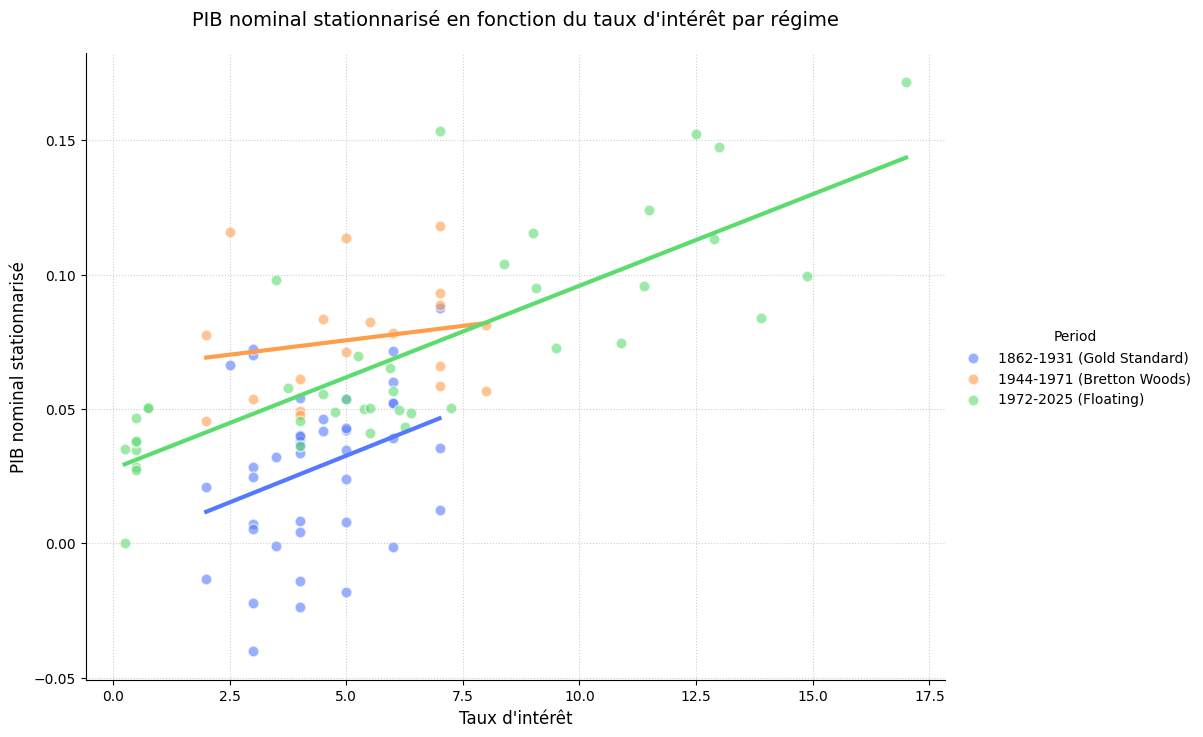

In [60]:
import seaborn as sns
#J'ai rajouté d_gold et Y_gdp pour pouvoir tracer la droite
C_gdp_plot = df_detrended[[
    'taux_directeur',
    'd_gold','d_woods', 'd_floating',
    'woods_int', 'floating_int',                                      
    'yield_perpetual_stat','oil_price_stat','gdp_trend_stat_stat','expected_inflation'                             
]]

# 1. On crée une copie propre pour le graphique
df_plot_gdp = C_gdp_plot.copy()
df_plot_gdp['Y_gdp'] = Y_gdp

# 2. On crée la colonne 'Period' en utilisant tes trois dummies
# On utilise .loc pour être précis
df_plot_gdp['Period'] = "Non classé" # Sécurité
df_plot_gdp.loc[df_plot_gdp['d_gold'] == 1, 'Period'] = '1862-1931 (Gold Standard)'
df_plot_gdp.loc[df_plot_gdp['d_woods'] == 1, 'Period'] = '1944-1971 (Bretton Woods)'
df_plot_gdp.loc[df_plot_gdp['d_floating'] == 1, 'Period'] = '1972-2025 (Floating)'
df_plot_gdp = df_plot_gdp[df_plot_gdp['Period'] != "Non classé"] #!!!!!!!!!!!!!!!!!!!!!!

# 3. Définition des couleurs identiques à ton image
palette_custom = {
    '1862-1931 (Gold Standard)': '#5479ff', # Bleu royal
    '1944-1971 (Bretton Woods)': '#ff9e4a', # Orange
    '1972-2025 (Floating)': '#5cdb6f',      # Vert herbe
    'Non classé': '#95a5a6' 
}

# 4. Tracé du graphique
# ci=None permet d'enlever les bandes de confiance pour que les droites soient très nettes
g = sns.lmplot(
    data=df_plot_gdp,
    x='taux_directeur', 
    y='Y_gdp', 
    hue='Period',
    palette=palette_custom,
    ci=None, 
    height=7,
    aspect=1.4,
    scatter_kws={'s': 60, 'alpha': 0.6, 'edgecolor': 'w'},
    line_kws={'linewidth': 3}
)

# 5. Cosmétique pour coller au style académique
plt.title("PIB nominal stationnarisé en fonction du taux d'intérêt par régime", fontsize=14, pad=20)
plt.xlabel("Taux d'intérêt", fontsize=12)
plt.ylabel('PIB nominal stationnarisé', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

#plt.show()

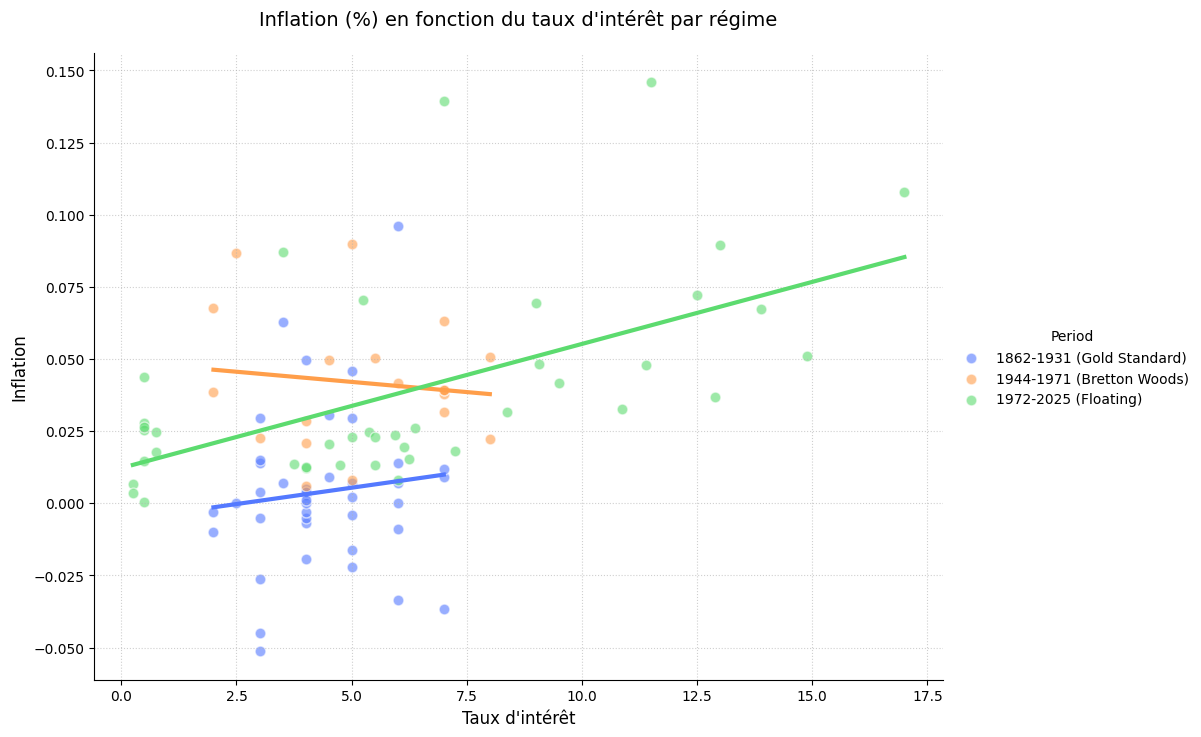

In [61]:
C_inf_plot = df_detrended[[
    'taux_directeur',
    'd_gold','d_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat'     
]]

df_plot_inf = C_inf_plot.copy()
df_plot_inf['Y_inflation'] = Y_inflation

df_plot_inf['Period'] = "Non classé" 
df_plot_inf.loc[df_plot_inf['d_gold'] == 1, 'Period'] = '1862-1931 (Gold Standard)'
df_plot_inf.loc[df_plot_inf['d_woods'] == 1, 'Period'] = '1944-1971 (Bretton Woods)'
df_plot_inf.loc[df_plot_inf['d_floating'] == 1, 'Period'] = '1972-2025 (Floating)'
df_plot_inf = df_plot_inf[df_plot_inf['Period'] != "Non classé"]

palette_custom = {
    '1862-1931 (Gold Standard)': '#5479ff', 
    '1944-1971 (Bretton Woods)': '#ff9e4a', 
    '1972-2025 (Floating)': '#5cdb6f',      
    'Non classé': '#95a5a6' 
}

g = sns.lmplot(
    data=df_plot_inf,
    x='taux_directeur', 
    y='Y_inflation', 
    hue='Period',
    palette=palette_custom,
    ci=None, 
    height=7,
    aspect=1.4,
    scatter_kws={'s': 60, 'alpha': 0.6, 'edgecolor': 'w'},
    line_kws={'linewidth': 3}
)

plt.title("Inflation (%) en fonction du taux d'intérêt par régime", fontsize=14, pad=20)
plt.xlabel("Taux d'intérêt", fontsize=12)
plt.ylabel('Inflation', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

#plt.show()

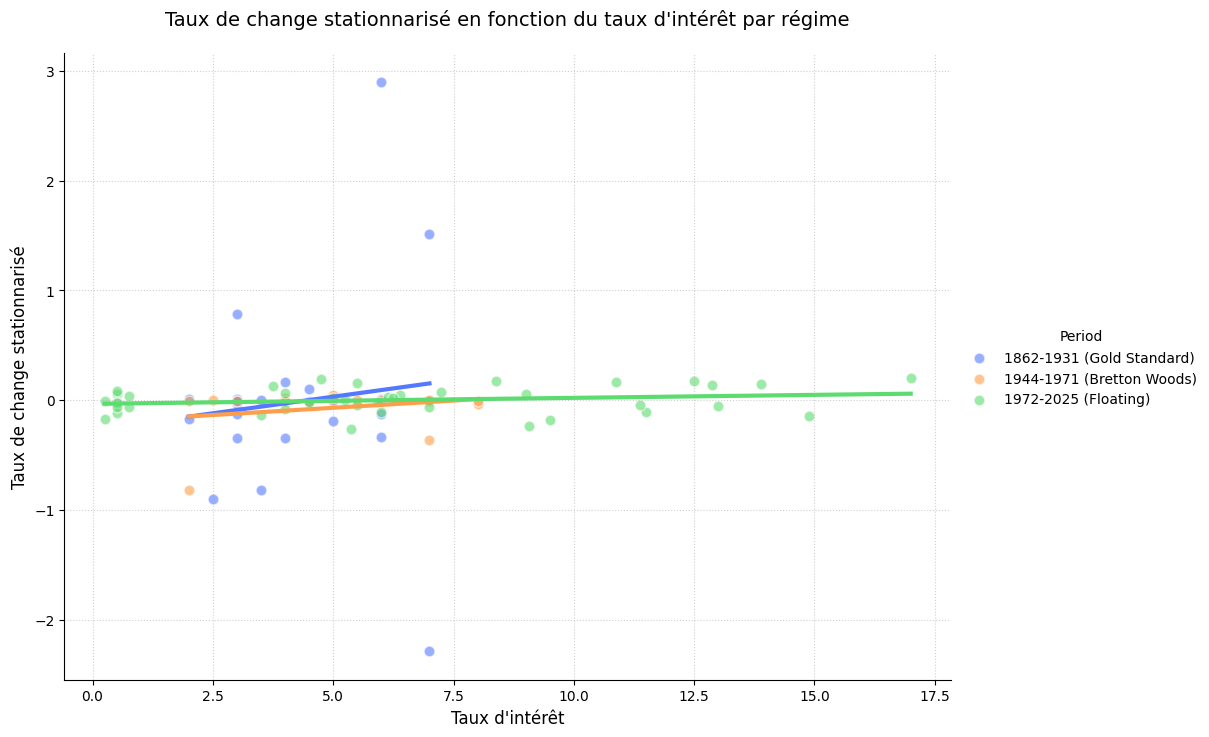

In [62]:
C_exch_plot = df_detrended[[
    'taux_directeur',
    'd_gold','d_woods', 'd_floating',
    'woods_int', 'floating_int', 
    'export_stat', 'import_stat_stat',       
    'yield_perpetual_stat',                  
    'oil_price_stat',                        
    'gdp_trend_stat_stat'     
]]

df_plot_exch = C_exch_plot.copy()
df_plot_exch['Y_change'] = Y_change

df_plot_exch['Period'] = "Non classé" 
df_plot_exch.loc[df_plot_exch['d_gold'] == 1, 'Period'] = '1862-1931 (Gold Standard)'
df_plot_exch.loc[df_plot_exch['d_woods'] == 1, 'Period'] = '1944-1971 (Bretton Woods)'
df_plot_exch.loc[df_plot_exch['d_floating'] == 1, 'Period'] = '1972-2025 (Floating)'
df_plot_exch = df_plot_exch[df_plot_exch['Period'] != "Non classé"]

palette_custom = {
    '1862-1931 (Gold Standard)': '#5479ff', 
    '1944-1971 (Bretton Woods)': '#ff9e4a', 
    '1972-2025 (Floating)': '#5cdb6f',      
    'Non classé': '#95a5a6' 
}

g = sns.lmplot(
    data=df_plot_exch,
    x='taux_directeur', 
    y='Y_change', 
    hue='Period',
    palette=palette_custom,
    ci=None, 
    height=7,
    aspect=1.4,
    scatter_kws={'s': 60, 'alpha': 0.6, 'edgecolor': 'w'},
    line_kws={'linewidth': 3}
)

plt.title("Taux de change stationnarisé en fonction du taux d'intérêt par régime", fontsize=14, pad=20)
plt.xlabel("Taux d'intérêt", fontsize=12)
plt.ylabel('Taux de change stationnarisé', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

#plt.show()

| | | |
|---|---|---|
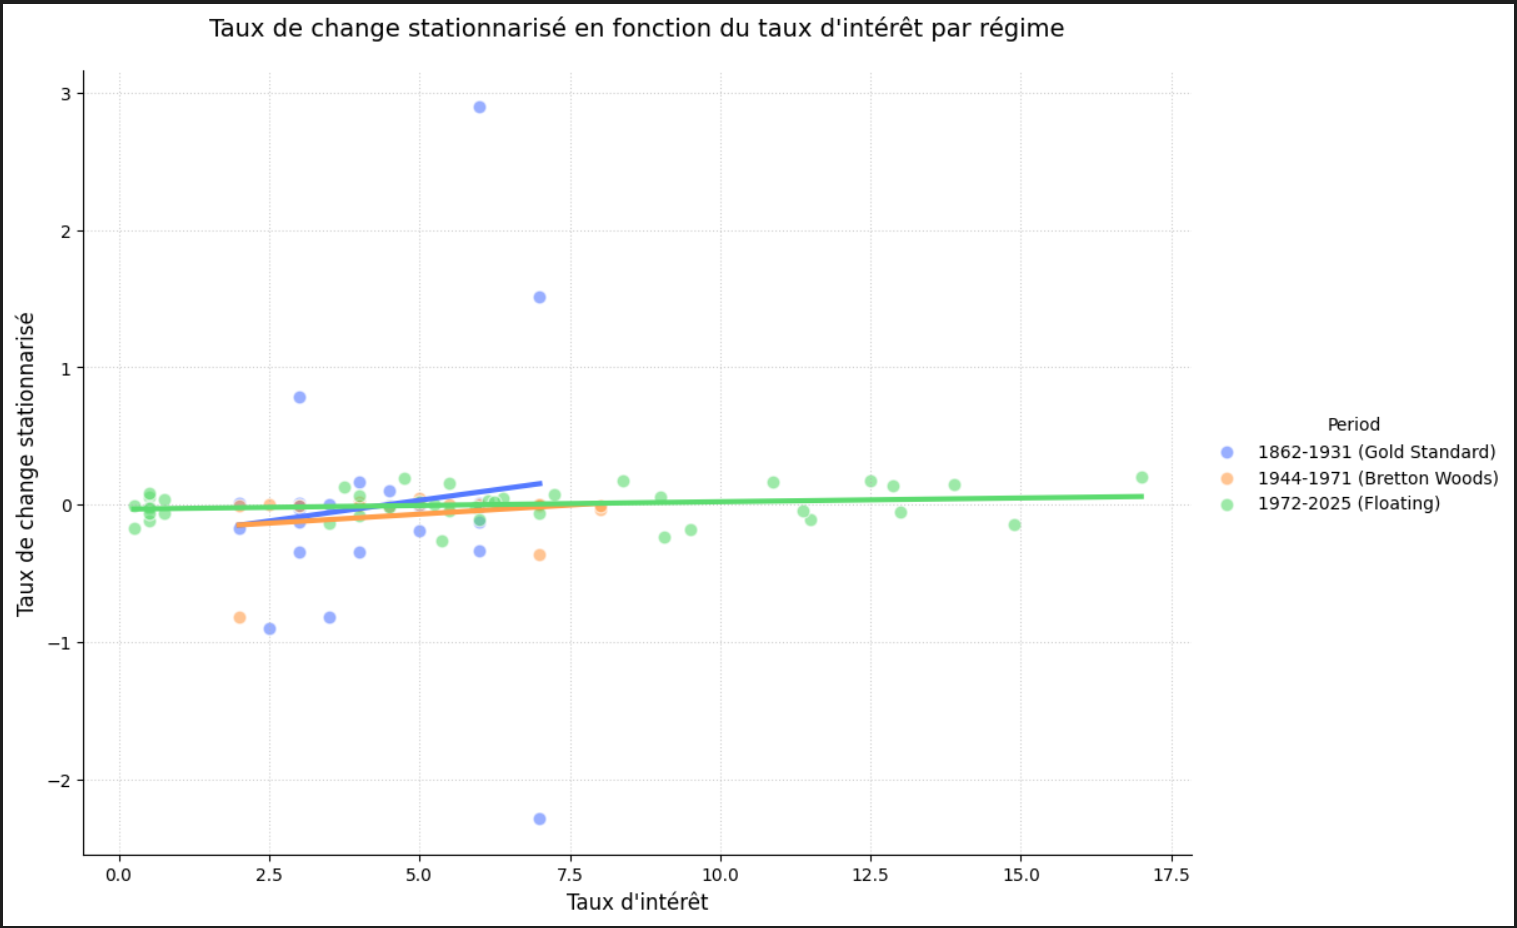 | 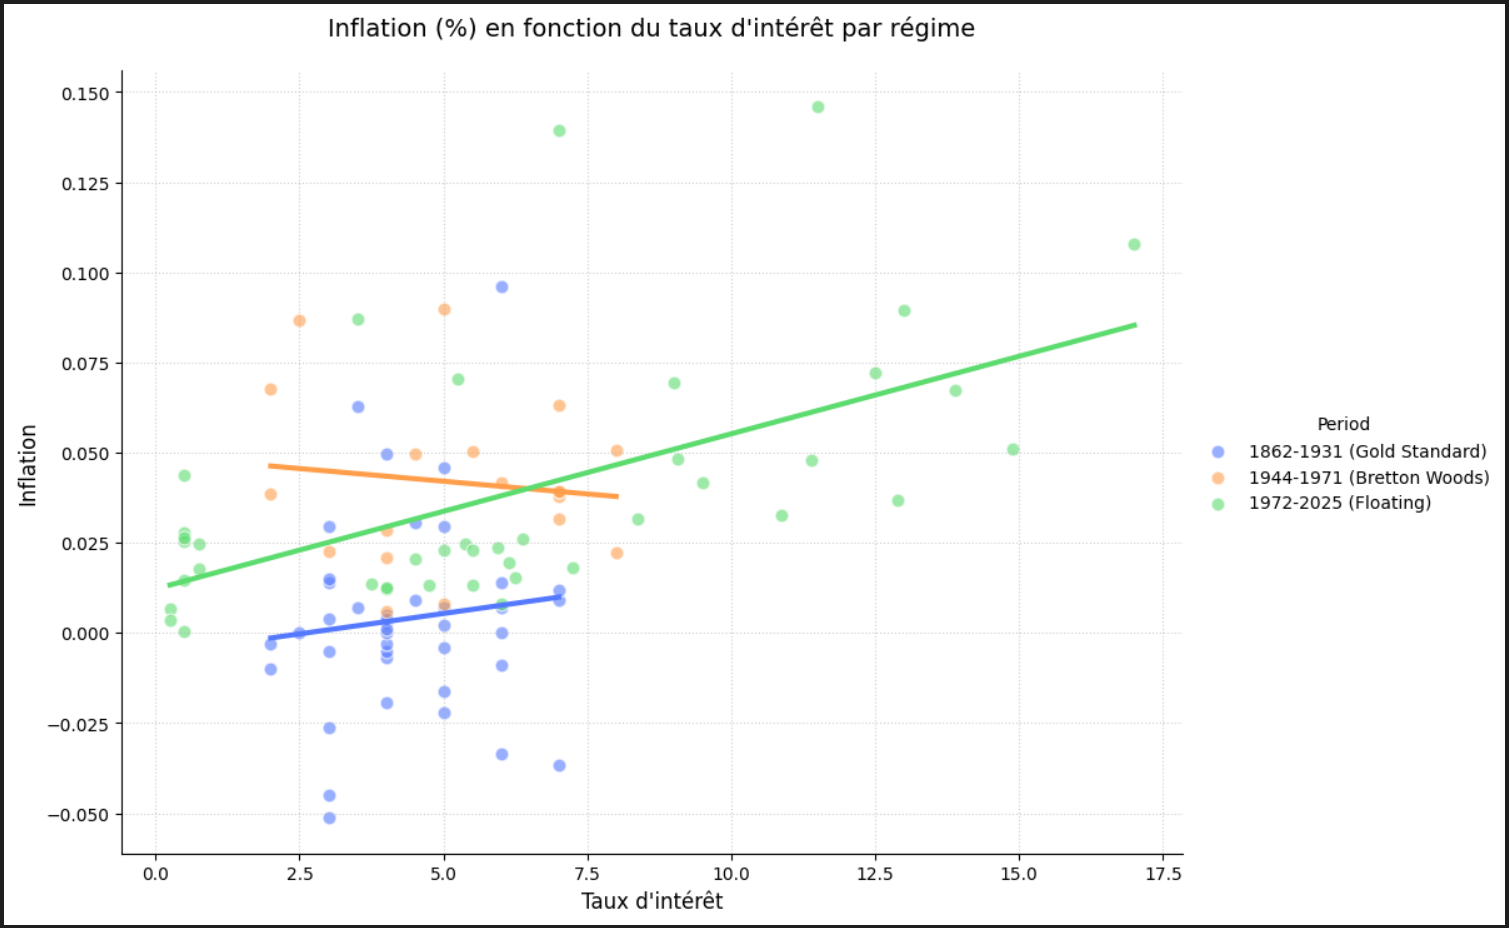 | 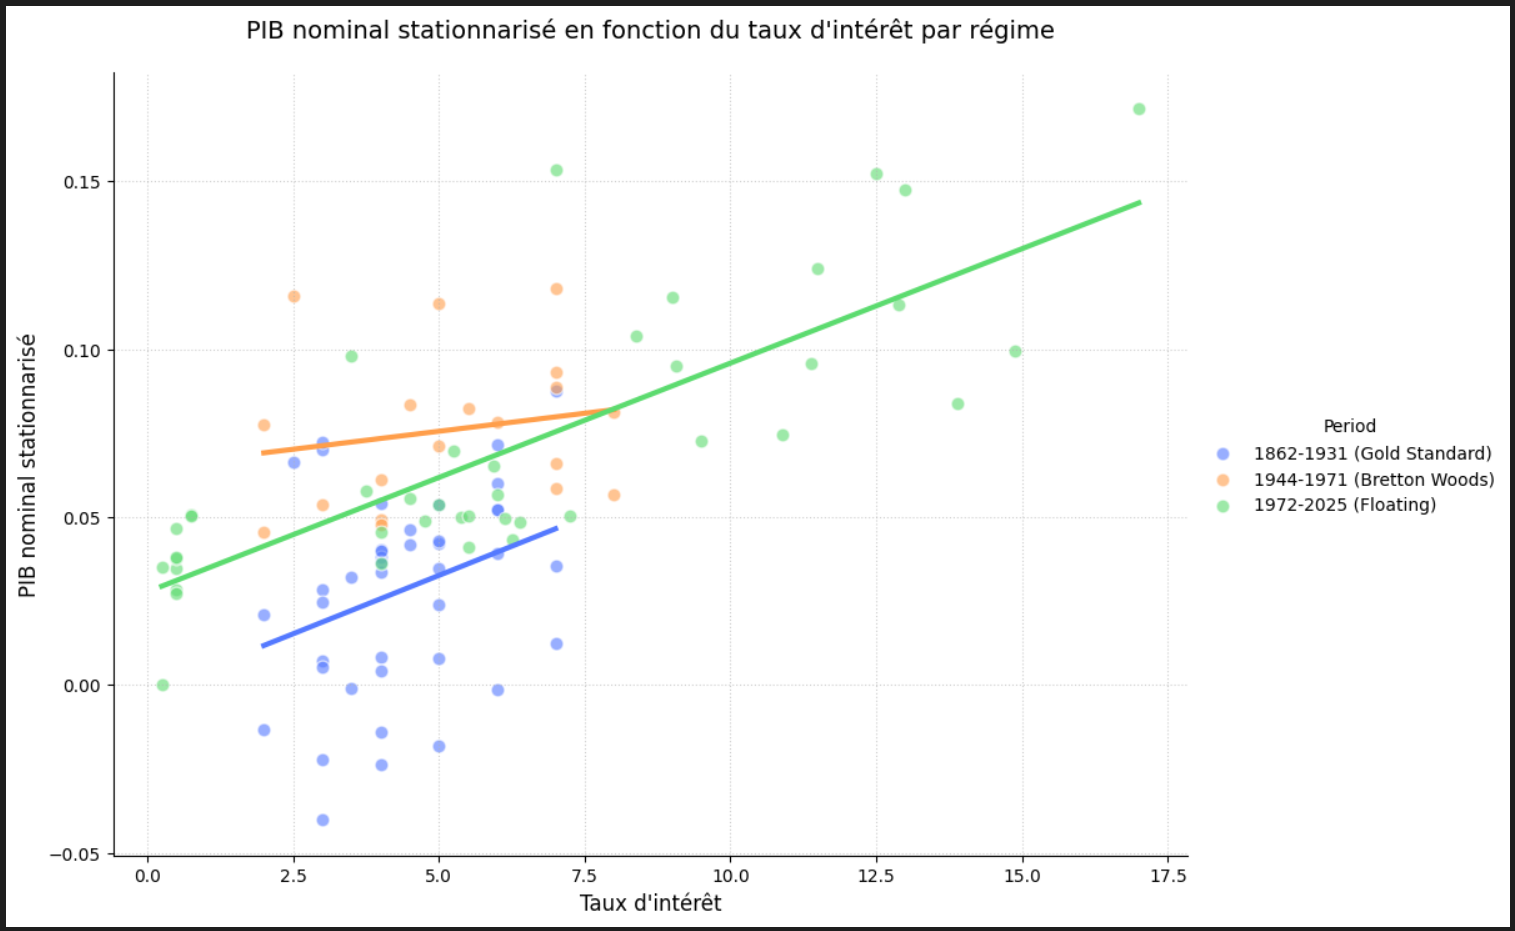

| | | |
|---|---|---|
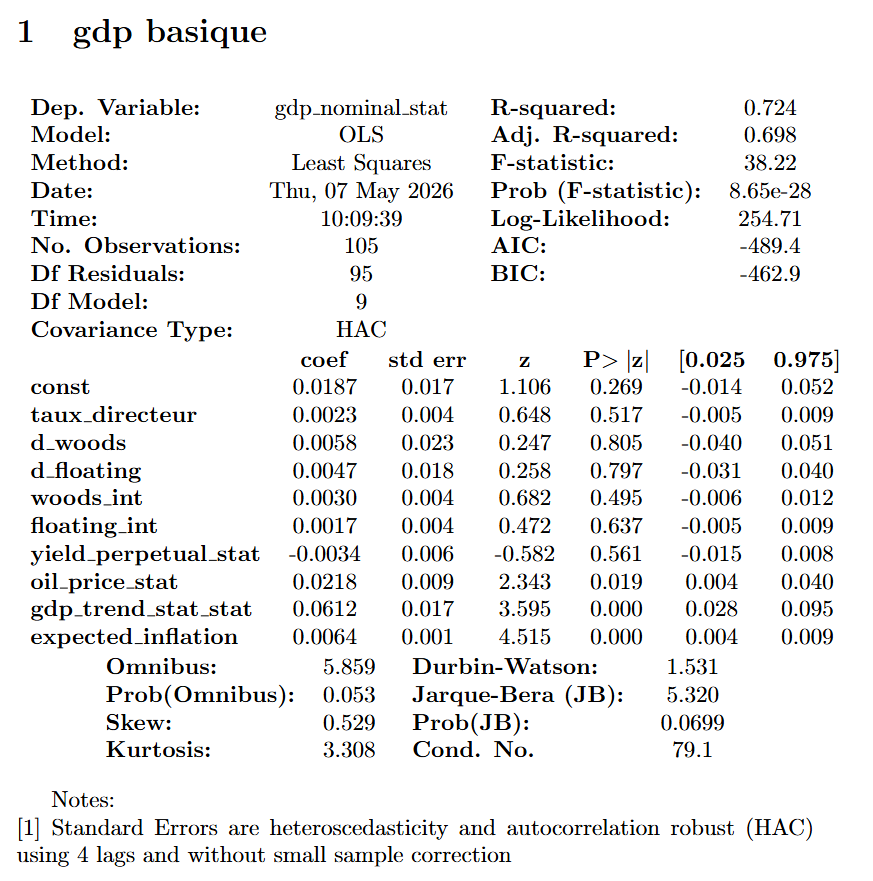 | 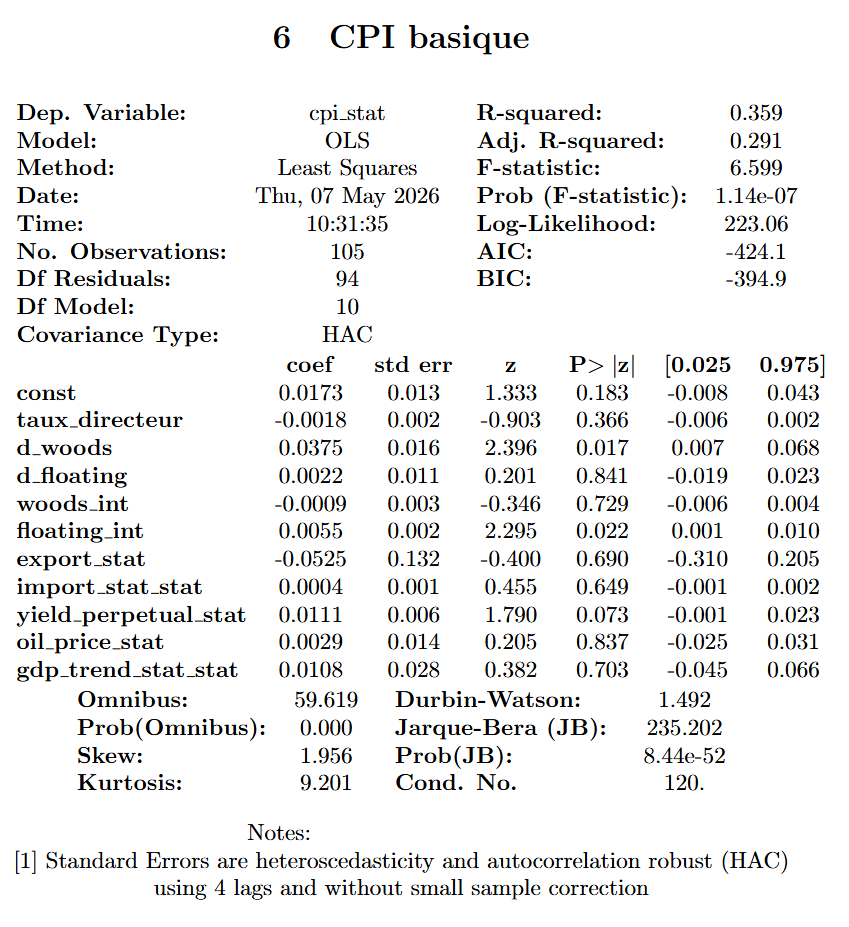 | 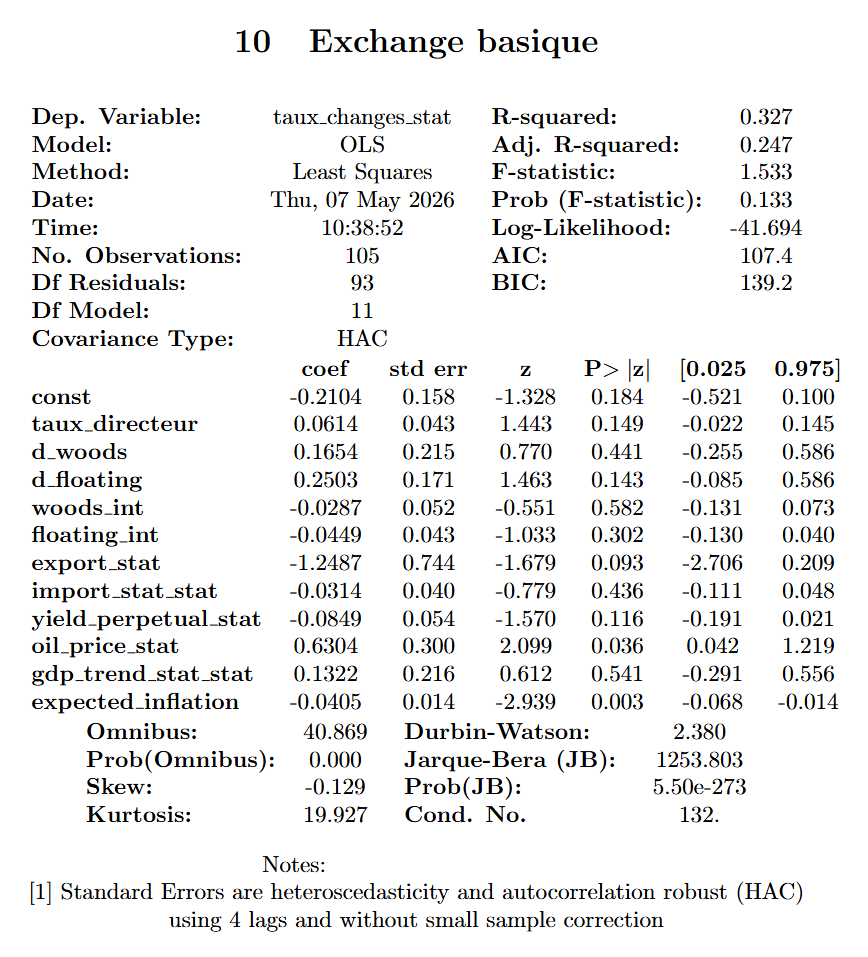

| | | |
|---|---|---|
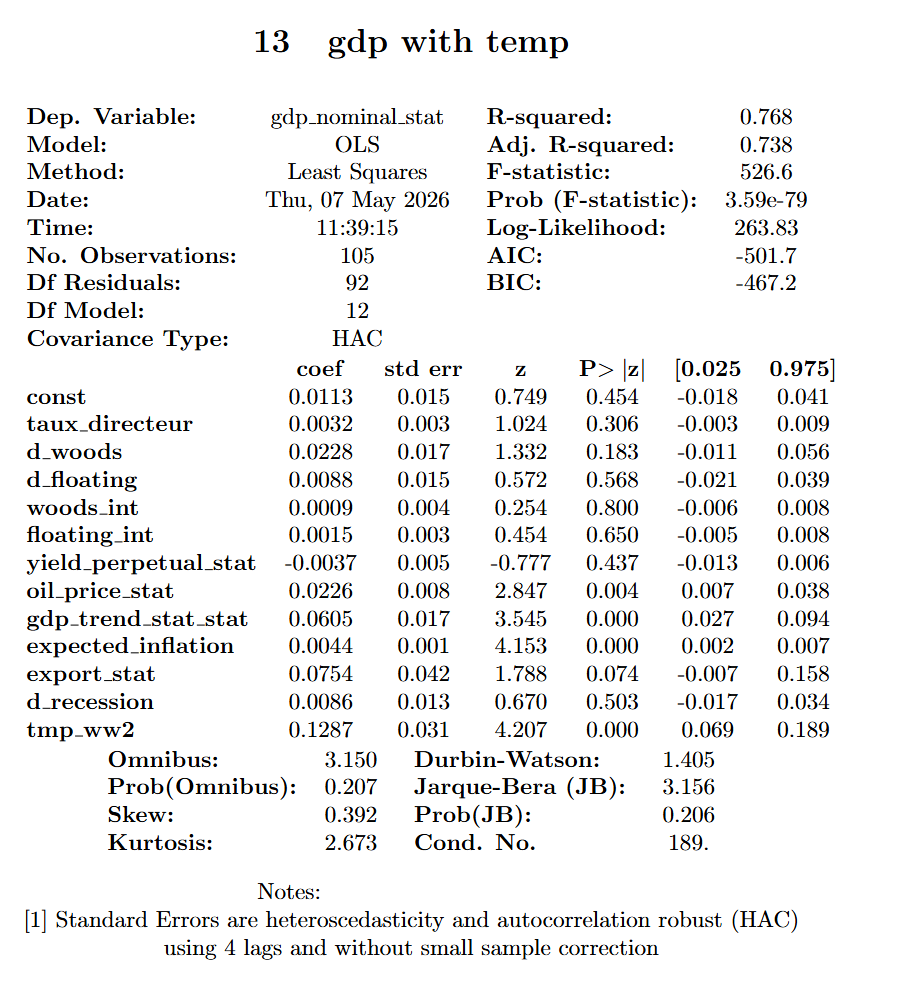 | 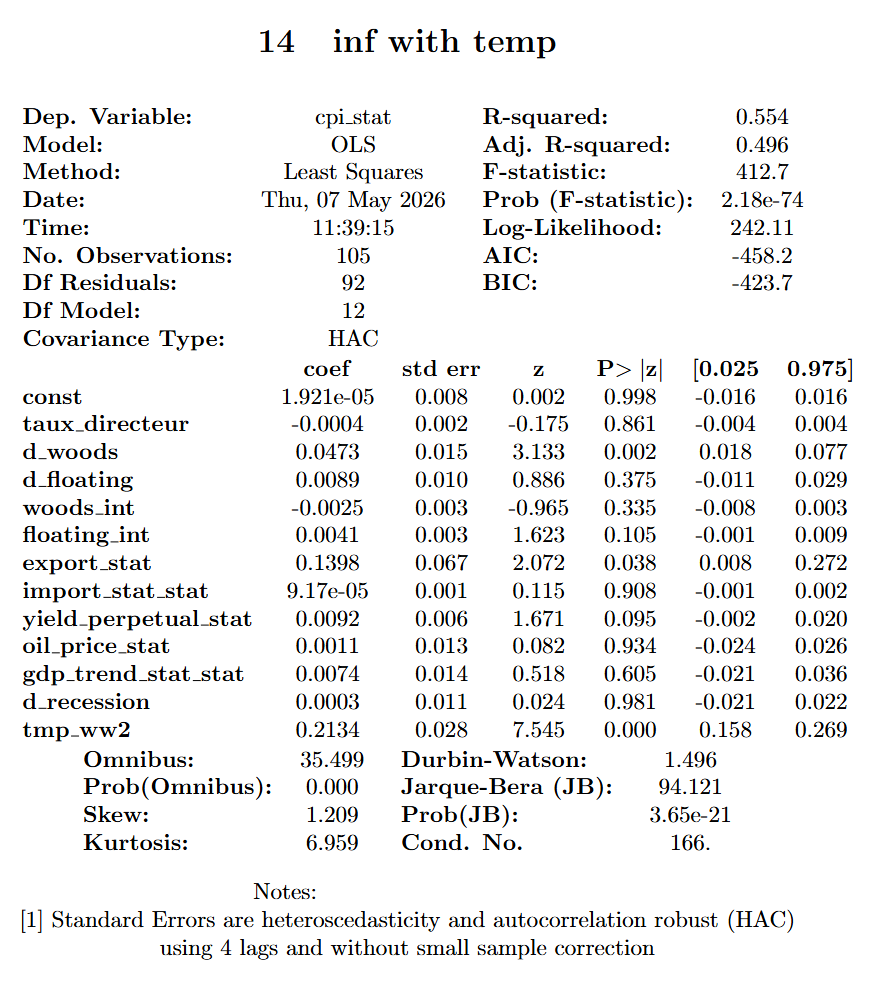 | 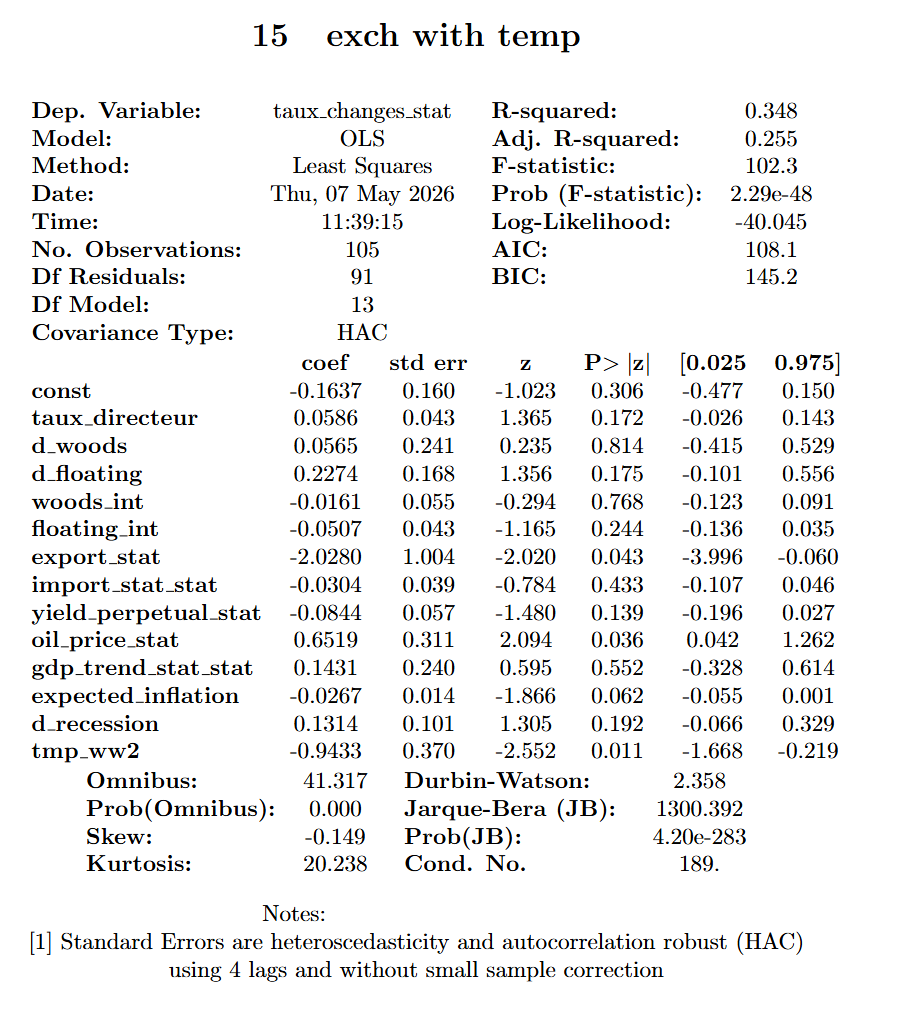